# Seaborn

## Overview

Seaborn is a high-level visualization library built on top of Matplotlib. It gives you cleaner defaults and concise plotting functions for statistical graphics, while still letting you use Matplotlib for fine-grained control.


### Seaborn vs Pandas vs Matplotlib

- **Pandas `.plot()`**
  - Best for fastest DataFrame-first plotting during quick EDA.
  - Minimal code and convenient defaults.
  - Limited statistical semantics and faceting compared with seaborn.

- **Matplotlib**
  - Lowest-level plotting foundation in Python.
  - Most flexible and precise control over figures, axes, and styling.
  - More verbose for common statistical plots.

- **Seaborn**
  - High-level statistical visualization built on Matplotlib.
  - Better defaults, cleaner aesthetics, and semantic mappings (`hue`, `style`, `size`).
  - Strong figure-level APIs for grouped/faceted views (`displot`, `relplot`, `catplot`).

Pandas plotting is excellent for fast, direct plotting from a DataFrame. Seaborn becomes stronger when you need **semantic mappings** (color/style/size by variables), cleaner statistical defaults, and grouped comparisons.

Practical rules:
- Start with **Pandas** for quick checks.
- Use **Seaborn** for statistical/grouped visuals.
- Drop to **Matplotlib** when you need exact low-level control.

In this notebook, we will use the following learning path:

1. Quick start (first useful plots)
2. Data model and semantic mappings (`hue`, `style`, `size`)
3. Core seaborn plot families (distribution, relational, categorical)
4. Figure-level wrappers and faceting (`displot`, `relplot`, `catplot`)
5. Multivariate views (`pairplot`, `jointplot`, `heatmap`)
6. Optional KDE internals appendix


By convention, Seaborn is imported as `sns`:

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# %pip install seaborn
import seaborn as sns

# Set consistent defaults for all following plots
sns.set_theme(style='whitegrid', context='notebook')

tips = sns.load_dataset('tips')
planets = sns.load_dataset('planets')
iris = sns.load_dataset('iris')
penguins = sns.load_dataset('penguins')

### Quick Comparison: Why Seaborn?

Compare the two plots in the next cell and you shall see that seaborn is giving more information about the data:

- Top plot (`pandas .plot.scatter()`): fast DataFrame-first plotting.
- Bottom plot (`sns.scatterplot()`): semantic mappings (`hue`, `style`, `size`) with cleaner statistical defaults.

Style note: this plot uses the global theme set earlier with `sns.set_theme(style='whitegrid', context='notebook')`.


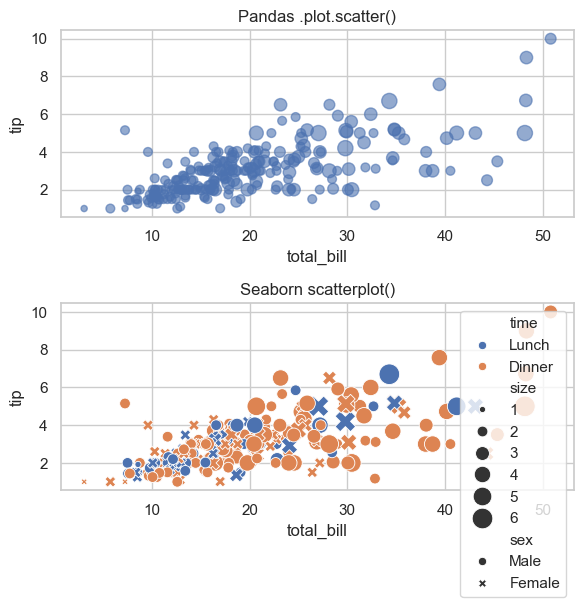

In [95]:
fig, ax = plt.subplots(2, 1, figsize=(6, 6))

# Pandas: fast DataFrame-first plotting
tips.plot(
    kind='scatter',
    x='total_bill', y='tip',
    s=tips['size'] * 20,
    alpha=0.6,
    ax=ax[0],
    title='Pandas .plot.scatter()'
)

# Seaborn: semantic mapping with clearer defaults
sns.scatterplot(
    data=tips,
    x='total_bill', y='tip',
    hue='time', style='sex', size='size',
    sizes=(20, 220),
    ax=ax[1]
)
ax[1].set_title('Seaborn scatterplot()')

plt.tight_layout()


## Quick Start

Let's start with a few axes-level examples. This gives you a fast way to recognize seaborn syntax before diving into API details. Here we see three different plotting functions of seaborn: `histplot()`, `scatterplot()`, and `boxplot()`. 


Let's take a look at the `tips` dataset.

In [106]:
tips.loc[:, ['total_bill', 'tip', 'size', 'day', 'time', 'sex']].head()

,total_bill,tip,size,day,time,sex
0,16.99,1.01,2,Sun,Dinner,Female
1,10.34,1.66,3,Sun,Dinner,Male
2,21.01,3.50,3,Sun,Dinner,Male
3,23.68,3.31,2,Sun,Dinner,Male
4,24.59,3.61,4,Sun,Dinner,Female


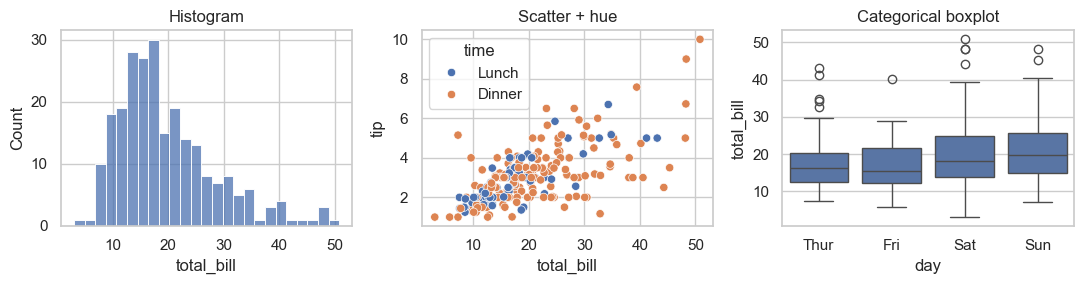

In [96]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3))

sns.histplot(data=tips, x='total_bill', bins=25, ax=ax[0])
ax[0].set_title('Histogram')

sns.scatterplot(data=tips, x='total_bill', y='tip', hue='time', ax=ax[1])
ax[1].set_title('Scatter + hue')

sns.boxplot(data=tips, x='day', y='total_bill', ax=ax[2])
ax[2].set_title('Categorical boxplot')

plt.tight_layout()


## Seaborn Data Model and Semantic Mappings

Seaborn works best with **tidy (long-form) data**:
- each column is a variable
- each row is one observation

Common semantic mappings:
- `hue`: map category/value to color
- `style`: map category to marker or line style
- `size`: map numeric values to marker size

Important distinction:
- Use `size=...` to map from data
- Use `s=...` for a constant marker size


## Data Formats

Data can be structured in different ways. Understanding these formats is essential because most Python visualization and analysis libraries, including Seaborn and pandas, expect data in a specific format. The common data formats are tidy, wide, and nested. 

| Format | Best For |
|--------|----------|
| Tidy | Seaborn, statsmodels, most analysis |
| Wide | Excel, quick inspection, some ML models |
| Nested | Raw API/JSON data before processing |

In practice, data often arrives in wide or nested format and should be converted to tidy before visualization or analysis.

### Tidy (Long) Format

In tidy data, each row is one observation, each column is one variable, and each cell holds one value. This is the preferred format for analysis and visualization.

In [97]:
import pandas as pd

tidy = pd.DataFrame({
    'student': ['Alice', 'Alice', 'Bob', 'Bob'],
    'subject': ['math', 'english', 'math', 'english'],
    'score':   [90, 85, 78, 88]
})
tidy

,student,subject,score
0,Alice,math,90
1,Alice,english,85
2,Bob,math,78
3,Bob,english,88


### Wide Format

In wide data, each row represents one subject, and variables are spread across multiple columns. This format is easier for humans to read at a glance.

In [98]:
wide = pd.DataFrame({
    'student': ['Alice', 'Bob'],
    'math':    [90, 78],
    'english': [85, 88]
})
wide

,student,math,english
0,Alice,90,85
1,Bob,78,88


### Nested Format

Nested data stores values inside dictionaries or lists, common when loading from JSON or APIs. It must be flattened before use.

In [99]:
nested = {
    'Alice': {'math': 90, 'english': 85},
    'Bob':   {'math': 78, 'english': 88}
}
nested

{'Alice': {'math': 90, 'english': 85}, 'Bob': {'math': 78, 'english': 88}}

### Converting Between Formats

In [104]:
students = pd.DataFrame({
    'student': ['Alice', 'Bob', 'Carol', 'David', 'Eve'],
    'gender':  ['F', 'M', 'F', 'M', 'F'],
    'grade':   [10, 10, 11, 11, 12],
    'math':    [90, 78, 85, 72, 95],
    'english': [85, 88, 80, 76, 92],
    'science': [92, 80, 88, 70, 96]
})

# Wide → Tidy
tidy = pd.melt(students, 
               id_vars=['student', 'gender', 'grade'],
               var_name='subject', 
               value_name='score')

# Tidy → Wide
wide = tidy.pivot(index='student',
                  columns='subject', values='score')

# Nested → Tidy
# Cleaner Nested → Tidy conversion
flat = pd.DataFrame(nested).T.reset_index()
flat.columns = ['student'] + list(flat.columns[1:])
flat = pd.melt(flat, id_vars='student',
               var_name='subject', value_name='score')

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# constant size points
sns.scatterplot(data=tips, x='total_bill', y='tip', s=80, ax=ax[0])
ax[0].set_title('Constant size (s=80)')

# size mapped from a real numeric column in the dataframe
sns.scatterplot(
    data=tips, x='total_bill', y='tip',
    hue='time', style='sex', size='size', sizes=(20, 220),
    ax=ax[1]
)
ax[1].set_title('Mapped hue/style/size')

plt.tight_layout()


## Axes-Level vs Figure-Level APIs

Seaborn has two common usage patterns:

- **Axes-level** functions (e.g., `histplot`, `scatterplot`, `lineplot`, `boxplot`) draw on a specific Matplotlib `ax` and return an `Axes`.
- **Figure-level** functions (e.g., `displot`, `relplot`, `catplot`) manage an entire figure/grid and return grid objects (`FacetGrid`, `JointGrid`, `PairGrid`).

Rule of thumb:
- Use axes-level for custom subplot composition.
- Use figure-level when faceting is the main goal.


<!-- <figure>
    <img src="../../images/sns_plot_chart.png" alt="Seaborn Plots Chart" width=400 >
    <figcaption><a src="https://seaborn.pydata.org/tutorial/function_overview.html">Seaborn Plots Chart</a></figcaption>
<figure> -->
```{figure} ../../images/sns_plot_chart.png 
:name: sns_plot_chart
:width: 375
:align: center
:alt: Seaborn Plots Chart
Seaborn Plots [Chart](https://seaborn.pydata.org/tutorial/function_overview.html)
``` 

The table below summarizes common figure-level functions and their typical axes-level backends.

| Figure-level | Typical axes-level backends | Typical use |
|---|---|---|
| `displot()` | `histplot()`, `kdeplot()`, `ecdfplot()` | Distribution views and facets |
| `relplot()` | `scatterplot()`, `lineplot()` | Relationships and facets |
| `catplot()` | `stripplot()`, `swarmplot()`, `boxplot()`, `violinplot()`, `barplot()`, `countplot()`, `pointplot()` | Categorical comparisons |
| `jointplot()` | scatter/KDE/hist/reg/hex styles | One variable pair + marginals |
| `pairplot()` | scatter/KDE/hist combinations | Pairwise numeric exploration |


## Distribution Plots

Distribution plots help you understand spread, skew, and shape of numerical variables.


### Histogram

A histogram groups values into bins and shows frequency in each bin.


In [ ]:
sns.histplot(data=tips, x='total_bill')

To control size, create an axes with Matplotlib and pass `ax=`:

In [ ]:
fig, axes = plt.subplots(figsize=(5, 3))
sns.histplot(data=tips, x='total_bill', bins=30, ax=axes)


Compare histogram APIs across pandas, Matplotlib, and seaborn:

- pandas: DataFrame-oriented convenience
- Matplotlib: lower-level direct control
- seaborn: statistical defaults and cleaner styling


In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3))

data = tips[['total_bill', 'tip']]

data.plot(ax=ax[0], kind='hist', title='Pandas plot(kind="hist")')

ax[1].hist(data, label=['total_bill', 'tip'])
ax[1].set_title('Matplotlib ax.hist()')
ax[1].legend()

sns.histplot(data=data, ax=ax[2])
ax[2].set_title('Seaborn histplot()')

plt.tight_layout()


In [ ]:
### Exercise: Histogram for Total Bill
#   1. Create a figure and axes with figsize=(5, 3).
#   2. Plot a histogram of tips['total_bill'] using sns.histplot.
#   3. Use bins=20.
#   4. Set the title to 'Total Bill Distribution'.
### Your code starts here.




### Your code ends here.


In [ ]:
### Solution
fig, ax = plt.subplots(figsize=(5, 3))
sns.histplot(data=tips, x='total_bill', bins=20, ax=ax)
ax.set_title('Total Bill Distribution')


### Bins, Alpha, and KDE

Three common controls:
- `bins`: granularity of histogram bars
- `alpha`: transparency
- `kde=True`: overlay smooth density estimate


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
bins = [30, 10]
for i, col in enumerate(data.columns):
    sns.histplot(data[col], bins=bins[i], label=col, ax=axes[i])
    axes[i].set_title(f'{col} w/ sns.histplot()')
    axes[i].legend()
plt.tight_layout()


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for i, col in enumerate(data.columns[:2]):
    sns.histplot(data[col], alpha=0.25, bins=30, ax=axes[i])
    axes[i].set_title(f'{col} alpha=0.25')
plt.tight_layout()


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for i, col in enumerate(data.columns):
    sns.histplot(data[col], alpha=0.5, bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'{col} + kde=True')
plt.tight_layout()


In [ ]:
### Exercise: Compare Histogram Settings
#   1. Create fig, axes = plt.subplots(1, 2, figsize=(8, 3)).
#   2. On axes[0], plot tips['tip'] with bins=10 and title 'bins=10'.
#   3. On axes[1], plot tips['tip'] with bins=30, alpha=0.4, kde=True,
#      and title 'bins=30, alpha=0.4, kde=True'.
#   4. Call plt.tight_layout().
### Your code starts here.




### Your code ends here.


In [ ]:
### Solution
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

sns.histplot(tips['tip'], bins=10, ax=axes[0])
axes[0].set_title('bins=10')

sns.histplot(tips['tip'], bins=30, alpha=0.4, kde=True, ax=axes[1])
axes[1].set_title('bins=30, alpha=0.4, kde=True')

plt.tight_layout()


### KDE / Density

KDE is a smooth estimate of a distribution. It is often useful alongside histograms.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
sns.kdeplot(data=data, alpha=0.5, ax=axes[0])
axes[0].set_title('KDE')

sns.kdeplot(data=data, fill=True, alpha=0.5, ax=axes[1])
axes[1].set_title('KDE w/ fill')

plt.tight_layout()


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

sns.kdeplot(data=data, x='total_bill', y='tip', ax=axes[0])
axes[0].set_title('2D KDE')

sns.scatterplot(data=data, x='total_bill', y='tip', ax=axes[1])
axes[1].set_title('Scatter')

plt.tight_layout()


In [ ]:
### Exercise: KDE for Two Variables
#   1. Create fig, axes = plt.subplots(1, 2, figsize=(8, 3)).
#   2. On axes[0], draw sns.kdeplot for tips['total_bill'] with fill=True.
#   3. On axes[1], draw sns.kdeplot for tips['tip'] with fill=True.
#   4. Title the plots 'total_bill KDE' and 'tip KDE'.
#   5. Call plt.tight_layout().
### Your code starts here.




### Your code ends here.


In [ ]:
### Solution
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

sns.kdeplot(tips['total_bill'], fill=True, ax=axes[0])
axes[0].set_title('total_bill KDE')

sns.kdeplot(tips['tip'], fill=True, ax=axes[1])
axes[1].set_title('tip KDE')

plt.tight_layout()


## Relational Plots

Relational plots show how variables move together (patterns, trends, clusters).


### Scatter Plot

In [ ]:
sns.scatterplot(x='total_bill', y='tip', data=tips, s=100, legend=True)

In [ ]:
### Exercise: Scatter with Semantic Mapping
#   1. Create a scatter plot of total_bill vs tip.
#   2. Color points by time (hue='time').
#   3. Use marker size mapping from the 'size' column with sizes=(30, 180).
#   4. Set the title to 'Tips: Bill vs Tip by Time and Party Size'.
### Your code starts here.




### Your code ends here.


In [ ]:
### Solution
ax = sns.scatterplot(
    data=tips,
    x='total_bill',
    y='tip',
    hue='time',
    size='size',
    sizes=(30, 180)
)
ax.set_title('Tips: Bill vs Tip by Time and Party Size')


### Line Plot

`lineplot` is commonly used for trends across an ordered x-axis. By default, seaborn aggregates repeated x values and can show uncertainty intervals.


In [ ]:
sns.lineplot(x='day', y='tip', data=tips, estimator='mean', errorbar=('ci', 95))

In [ ]:
### Exercise: Average Tip by Day
#   1. Create a line plot with x='day' and y='tip' using the tips dataset.
#   2. Use estimator='mean'.
#   3. Keep a 95% confidence interval using errorbar=('ci', 95).
#   4. Set the title to 'Average Tip by Day'.
### Your code starts here.




### Your code ends here.


In [ ]:
### Solution
ax = sns.lineplot(x='day', y='tip', data=tips, estimator='mean', errorbar=('ci', 95))
ax.set_title('Average Tip by Day')


## Categorical Plots

Categorical plots summarize or compare values across groups.


`sns.catplot()` is a figure-level wrapper for categorical plots (`kind='box'`, `'violin'`, `'bar'`, `'count'`, etc.).

Use it when you want consistent faceting/layout behavior across categorical plot types.


### Box Plot

In [ ]:
with sns.axes_style(style='ticks'):
    g = sns.catplot(x='day', y='total_bill', hue='sex', data=tips, kind='box')
    g.set_axis_labels('Day', 'Total Bill')


In [ ]:
### Exercise: Box Plot by Day and Sex
#   1. Use sns.catplot with kind='box'.
#   2. Plot x='day', y='total_bill', and hue='sex' from tips.
#   3. Set axis labels to 'Day' and 'Total Bill'.
### Your code starts here.




### Your code ends here.


In [ ]:
### Solution
g = sns.catplot(x='day', y='total_bill', hue='sex', data=tips, kind='box')
g.set_axis_labels('Day', 'Total Bill')


### Bar Plot (`kind='bar'`)

`bar` shows an **estimator** (mean by default) with uncertainty intervals.


In [ ]:
with sns.axes_style(style='dark'):
    g = sns.catplot(x='day', y='total_bill', data=tips, kind='bar', errorbar=('ci', 95))
    g.set_axis_labels('Day', 'Total Bill')


In [ ]:
with sns.axes_style(style='dark'):
    g = sns.catplot(x='day', y='total_bill', hue='sex', data=tips, kind='bar', errorbar=('ci', 95))
    g.set_axis_labels('Day', 'Total Bill')


In [ ]:
### Exercise: Mean Total Bill by Day
#   1. Create a categorical bar plot with x='day' and y='total_bill'.
#   2. Use kind='bar' and errorbar=('ci', 95).
#   3. Set axis labels to 'Day' and 'Total Bill'.
### Your code starts here.




### Your code ends here.


In [ ]:
### Solution
g = sns.catplot(x='day', y='total_bill', data=tips, kind='bar', errorbar=('ci', 95))
g.set_axis_labels('Day', 'Total Bill')


### Count Plot (`kind='count'`)

Count plots show category frequencies. This is different from histograms, which bin continuous numeric values.


In [ ]:
with sns.axes_style('white'):
    g = sns.catplot(
        x='year',
        data=planets,
        aspect=2,
        kind='count',
        color='steelblue',
        height=3
    )
    g.set_xticklabels(step=5)


In [ ]:
### Exercise: Count Planets Discoveries by Year
#   1. Create a count plot using planets with x='year'.
#   2. Use kind='count', height=3, aspect=2, and color='steelblue'.
#   3. Set x tick labels to show every 5th year.
### Your code starts here.




### Your code ends here.


In [ ]:
### Solution
g = sns.catplot(
    x='year',
    data=planets,
    kind='count',
    height=3,
    aspect=2,
    color='steelblue'
)
g.set_xticklabels(step=5)


## Figure-Level Wrappers and Faceting

Use figure-level wrappers when you want seaborn to build panel grids directly from grouping variables.


These wrappers make small-multiple comparisons much easier (`row=`, `col=`, `hue=`, `height=`, `aspect=`).


In [ ]:
sns.displot(data=tips, x='total_bill', col='time', kde=True, height=3, aspect=1.2)

In [ ]:
sns.relplot(
    data=tips,
    x='total_bill', y='tip',
    hue='sex', col='time', row='smoker',
    kind='scatter', height=3, aspect=1
)

In [ ]:
sns.catplot(
    data=tips,
    x='day', y='total_bill', hue='sex', col='time',
    kind='box', height=3, aspect=1
)

### Manual FacetGrid Example

In [ ]:
tips['tip_pct'] = 100 * tips['tip'] / tips['total_bill']

grid = sns.FacetGrid(data=tips, row='sex', col='time', margin_titles=True)
grid.map(plt.hist, 'tip_pct', bins=np.linspace(0, 40, 15))


In [ ]:
### Exercise: Faceted Tip Percentage Histograms
#   1. Create tips['tip_pct'] as 100 * tip / total_bill.
#   2. Build a FacetGrid with row='sex' and col='time'.
#   3. Map plt.hist on 'tip_pct' using bins=np.linspace(0, 40, 15).
### Your code starts here.




### Your code ends here.


In [ ]:
### Solution
tips['tip_pct'] = 100 * tips['tip'] / tips['total_bill']
grid = sns.FacetGrid(data=tips, row='sex', col='time', margin_titles=True)
grid.map(plt.hist, 'tip_pct', bins=np.linspace(0, 40, 15))


## Multivariate Views

These plots help you inspect relationships among multiple variables at once.


### Pair Plots

In [ ]:
sns.pairplot(tips)

In [ ]:
sns.pairplot(tips, hue='sex', palette='coolwarm')

In [ ]:
sns.pairplot(iris, hue='species', height=1.5)

In [ ]:
### Exercise: Pairplot with Group Coloring
#   1. Create a pairplot using the iris dataset.
#   2. Color points by species using hue='species'.
#   3. Set height=1.5 for each subplot.
### Your code starts here.




### Your code ends here.


In [ ]:
### Solution
sns.pairplot(iris, hue='species', height=1.5)


### Joint Plots

In [ ]:
sns.jointplot(x='total_bill', y='tip', data=tips, kind='scatter')

In [ ]:
with sns.axes_style('white'):
    sns.jointplot(x='total_bill', y='tip', data=tips, kind='hex')


In [ ]:
sns.jointplot(x='total_bill', y='tip', data=tips, kind='reg')

In [ ]:
### Exercise: Joint Plot with Regression
#   1. Create a joint plot of total_bill vs tip from tips.
#   2. Use kind='reg'.
#   3. Keep default marginal distributions.
### Your code starts here.




### Your code ends here.


In [ ]:
### Solution
sns.jointplot(x='total_bill', y='tip', data=tips, kind='reg')


### Heatmap (Common EDA Pattern)

Heatmaps are useful for compact matrix-style summaries, such as correlation matrices.


In [ ]:
corr = tips[['total_bill', 'tip', 'size']].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(corr, annot=True, cmap='Blues', vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation Heatmap')


In [ ]:
### Exercise: Correlation Heatmap
#   1. Compute a correlation matrix from ['total_bill', 'tip', 'size'].
#   2. Plot a heatmap with annot=True and cmap='Blues'.
#   3. Set vmin=-1 and vmax=1.
#   4. Add title 'Tips Correlation Heatmap'.
### Your code starts here.




### Your code ends here.


In [ ]:
### Solution
corr = tips[['total_bill', 'tip', 'size']].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(corr, annot=True, cmap='Blues', vmin=-1, vmax=1, ax=ax)
ax.set_title('Tips Correlation Heatmap')


## Themes and Global Style

Seaborn theme settings apply globally in the notebook and help keep plots visually consistent.


Seaborn theme settings apply globally in the notebook and help keep plots consistent.

In [ ]:
sns.set_theme(style='ticks', context='talk', palette='deep')
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='time')


In [ ]:
# Reset to a moderate default for the rest of your work
sns.set_theme(style='whitegrid', context='notebook')


## Appendix (Optional): Why KDE Looks Smooth

This section is optional and focuses on intuition for KDE construction.


`rugplot` marks each observation on one axis. A KDE can be viewed as the sum of many smooth kernels centered on those observations.

In [ ]:
sns.rugplot(tips['total_bill'])

In [ ]:
# Don't worry about understanding this code in depth.
# It visualizes how summing basis functions forms a KDE-like curve.
from scipy import stats

# Create dataset
np.random.seed(42)
dataset = np.random.randn(25)

sns.rugplot(dataset)

x_min = dataset.min() - 2
x_max = dataset.max() + 2
x_axis = np.linspace(x_min, x_max, 100)

bandwidth = ((4 * dataset.std()**5) / (3 * len(dataset)))**.2

kernel_list = []
for data_point in dataset:
    kernel = stats.norm(data_point, bandwidth).pdf(x_axis)
    kernel_list.append(kernel)

    kernel = kernel / kernel.max()
    kernel = kernel * .4
    plt.plot(x_axis, kernel, color='grey', alpha=0.5)

plt.ylim(0, 1)


In [ ]:
sum_of_kde = np.sum(kernel_list, axis=0)
plt.plot(x_axis, sum_of_kde, color='indianred')
sns.rugplot(dataset, color='indianred')
plt.yticks([])
plt.suptitle('Sum of the Basis Functions')


### Final Note

Use this rule of thumb:
- Use axes-level functions for custom subplot composition.
- Use figure-level wrappers when faceting/small multiples are the goal.
